# Statistical Modeling and Inferencing

## Assignment 1

### Customer Segmentation using the Mall Customer Dataset

---

### Submitted By

**Name:** Suhrita Maji

**BITS ID:** 2025EM1300071

**Course:** M.Sc. Data Science and Artificial Intelligence

**Assignment:** Assignment 1

**Dataset:** Mall Customer Segmentation Dataset

**Submission Date:** 8 August 2026

---

# Summary

In this assignment, I analyzed the Mall Customer Segmentation dataset to identify groups of customers with similar characteristics. The main objective was to understand customer behavior by applying clustering techniques and to explore how different customer attributes contribute to meaningful customer segments.

I started by exploring the dataset, checking its structure, descriptive statistics, missing values, and possible outliers. I also visualized the data to understand the distribution of different features and their relationships. After preprocessing the data, I applied feature scaling to prepare it for clustering.

For the analysis, I used both K-Means Clustering and Hierarchical Clustering. The optimal number of clusters was determined using the Elbow Method and Silhouette Score, and Principal Component Analysis (PCA) was used to visualize the clusters. Finally, I interpreted the results, discussed the limitations of the analysis, and provided recommendations based on the findings.

# Part 1: Data Exploration and Preparation

The first step of any data analysis project is to understand the dataset before applying any machine learning techniques. In this section, I explore the structure of the dataset, examine the variables, identify any data quality issues, and perform the necessary preprocessing steps. I also use descriptive statistics and visualizations to better understand the data and prepare it for clustering analysis.

## 1.1 Importing Required Libraries

To perform data exploration, preprocessing, visualization, and clustering, I imported the required Python libraries. Each library provides specific functions that will be used throughout the analysis.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering algorithms
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

# Model evaluation
from sklearn.metrics import silhouette_score

# Dimensionality reduction
from sklearn.decomposition import PCA

# Hierarchical clustering
from scipy.cluster.hierarchy import linkage, dendrogram

# Display plots inside the notebook
%matplotlib inline

# Improve plot appearance
plt.style.use('default')
sns.set_theme(style="whitegrid")

## 1.2 Loading the Dataset

After importing the required libraries, I loaded the Mall Customer Segmentation dataset into a pandas DataFrame. This allows me to inspect the data, perform preprocessing, and carry out the analysis.

In [2]:
# Load the dataset
df = pd.read_csv("Mall_Customers.csv")

# Display the first five rows
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Initial Observation

The dataset was loaded successfully, and the first five records were displayed to verify that the data was imported correctly. The dataset contains customer demographic information such as gender, age, annual income, and spending score. Each row represents a unique customer identified by the `CustomerID` column.

## 1.3 Understanding the Dataset Structure

Before performing any analysis, I examined the size and structure of the dataset. This helps in understanding the available features, identifying data types, and checking whether any preprocessing is required before applying clustering algorithms.

In [3]:
# Display the number of rows and columns
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumns in the dataset:")
print(df.columns)

# Display dataset information
print("\nDataset Information:")
df.info()

Dataset Shape: (200, 5)

Columns in the dataset:
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


### Observation

The dataset contains **200 customer records** and **5 variables**. Four variables are numerical (`CustomerID`, `Age`, `Annual Income (k$)`, and `Spending Score (1-100)`), while `Gender` is a categorical variable.

All five columns contain **200 non-null values**, indicating that the dataset does not contain any missing values. The `CustomerID` column is a unique identifier and does not provide meaningful information for clustering. Therefore, it will be excluded during the preprocessing stage.

## 1.4 Descriptive Statistics

To better understand the numerical features in the dataset, I generated descriptive statistics. These statistics provide a summary of the central tendency, variability, and distribution of the numerical variables, helping identify potential patterns or unusual values before proceeding with clustering.

In [5]:
# Generate descriptive statistics for numerical columns
df.describe().round(2)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00,200.00
mean,100.50,38.85,60.56,50.20
std,57.88,13.97,26.26,25.82
min,1.00,18.00,15.00,1.00
25%,50.75,28.75,41.50,34.75
50%,100.50,36.00,61.50,50.00
75%,150.25,49.00,78.00,73.00
max,200.00,70.00,137.00,99.00


### Interpretation

The descriptive statistics provide an overview of the numerical features in the dataset. All numerical variables contain 200 observations, indicating that there are no missing values.

The average customer is approximately 39 years old, with an average annual income of 60.56 k$ and an average spending score of 50.20. The standard deviation values indicate a reasonable variation in age, income, and spending score, suggesting that the dataset contains customers with diverse characteristics.

The minimum and maximum values show that the dataset covers a broad range of customer ages, income levels, and spending behaviors. The mean and median values are relatively close for the numerical variables, indicating that there is no strong evidence of extreme skewness based on the summary statistics alone.

# 1.5 Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) was performed to better understand the distribution of the variables and identify any patterns or anomalies in the dataset. Different visualizations were used to examine numerical and categorical variables before proceeding with preprocessing and clustering.

### 1.5.1 Distribution of Numerical Variables

Histograms were used to examine the distribution of the numerical variables, including Age, Annual Income, and Spending Score. These plots help identify the spread of the data, common value ranges, and any noticeable skewness.

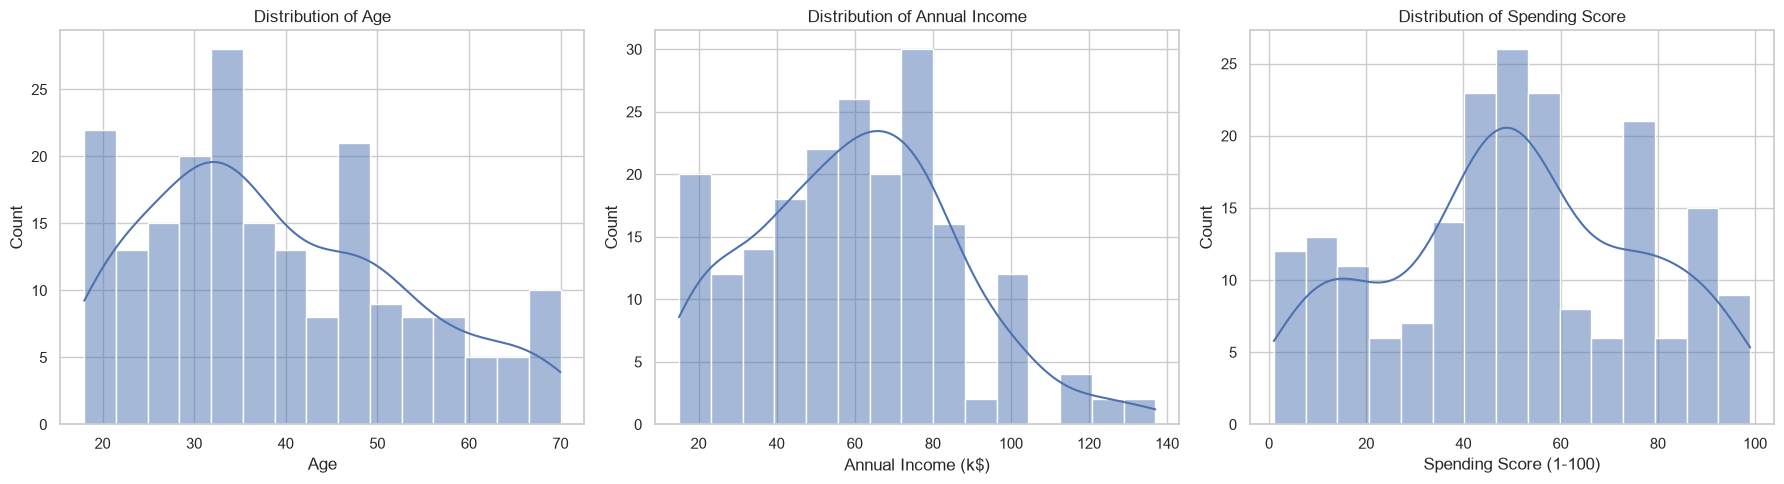

In [7]:
# Create histograms for numerical features

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age
sns.histplot(df["Age"], bins=15, kde=True, ax=axes[0])
axes[0].set_title("Distribution of Age")

# Annual Income
sns.histplot(df["Annual Income (k$)"], bins=15, kde=True, ax=axes[1])
axes[1].set_title("Distribution of Annual Income")

# Spending Score
sns.histplot(df["Spending Score (1-100)"], bins=15, kde=True, ax=axes[2])
axes[2].set_title("Distribution of Spending Score")

plt.tight_layout()
plt.show()

### Interpretation

The histograms provide an overview of the distribution of the numerical variables in the dataset.

- **Age:** Most customers are between 20 and 40 years old, while relatively fewer customers belong to the older age groups. The distribution is slightly right-skewed, indicating that younger customers are more common in the dataset.

- **Annual Income:** Annual income ranges from 15 k$ to 137 k$. Most customers have an annual income between 40 k$ and 80 k$, with only a few customers in the higher income range.

- **Spending Score:** The spending score is distributed across the entire range of values, indicating that the dataset includes customers with low, moderate, and high spending behavior. This variation is beneficial for identifying meaningful customer segments through clustering.

### 1.5.2 Distribution of Gender

Since Gender is the only categorical variable in the dataset, a count plot was used to examine its distribution.

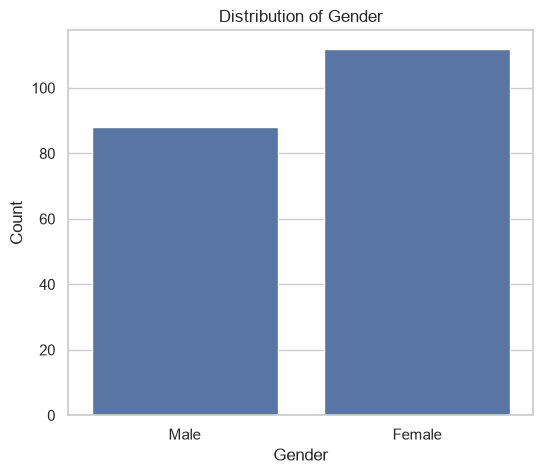

In [8]:
# Distribution of Gender

plt.figure(figsize=(6,5))

sns.countplot(data=df, x="Gender")

plt.title("Distribution of Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

### Interpretation

The count plot shows that the dataset contains slightly more female customers than male customers. Both genders are well represented, making the dataset suitable for analysis without any noticeable class imbalance. Since `Gender` is a categorical variable, it will be encoded into numerical values during the preprocessing stage before applying clustering algorithms.

### 1.5.3 Outlier Detection

To identify potential outliers in the numerical variables, I used boxplots. Boxplots provide a visual summary of the data distribution and help detect observations that lie significantly outside the typical range of the dataset.

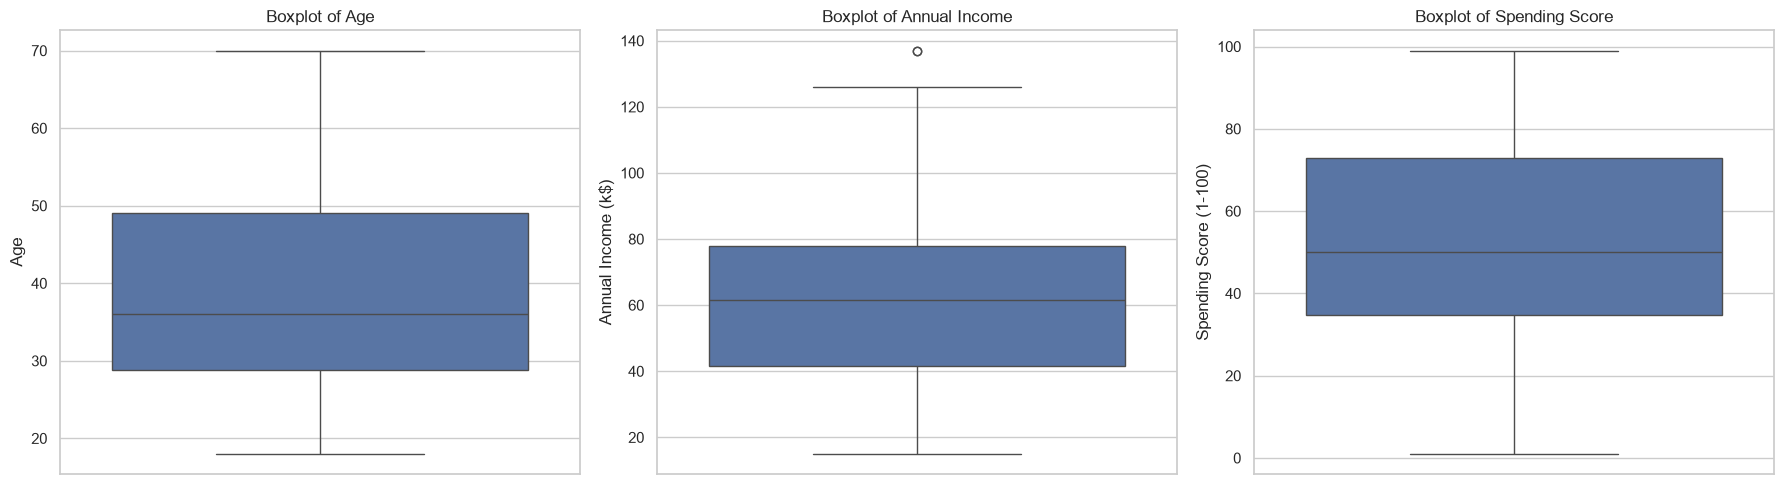

In [9]:
# Create boxplots for numerical features

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Age
sns.boxplot(y=df["Age"], ax=axes[0])
axes[0].set_title("Boxplot of Age")

# Annual Income
sns.boxplot(y=df["Annual Income (k$)"], ax=axes[1])
axes[1].set_title("Boxplot of Annual Income")

# Spending Score
sns.boxplot(y=df["Spending Score (1-100)"], ax=axes[2])
axes[2].set_title("Boxplot of Spending Score")

plt.tight_layout()
plt.show()

### Interpretation

The boxplots were used to examine the presence of potential outliers in the numerical variables.

The **Age** and **Spending Score** variables do not show any noticeable outliers, as all observations fall within the whiskers of the boxplots.

For **Annual Income (k$)**, one observation appears above the upper whisker, indicating a potential high-income outlier. Since this value may represent a genuine customer rather than an error in the data, it will be retained for further analysis.

### Verifying Outliers Using the Interquartile Range (IQR)

Although the boxplots provide a visual indication of potential outliers, I also verified them mathematically using the Interquartile Range (IQR) method. This confirms whether any observations fall outside the acceptable range based on the standard outlier detection rule.

In [10]:
# Select numerical columns (excluding CustomerID)
numerical_columns = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

for column in numerical_columns:

    # Calculate Q1 and Q3
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    # Calculate IQR
    IQR = Q3 - Q1

    # Calculate lower and upper limits
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # Find outliers
    outliers = df[(df[column] < lower_limit) | (df[column] > upper_limit)]

    print(f"\n{column}")
    print(f"Lower Limit : {lower_limit:.2f}")
    print(f"Upper Limit : {upper_limit:.2f}")
    print(f"Number of Outliers : {len(outliers)}")


Age
Lower Limit : -1.62
Upper Limit : 79.38
Number of Outliers : 0

Annual Income (k$)
Lower Limit : -13.25
Upper Limit : 132.75
Number of Outliers : 2

Spending Score (1-100)
Lower Limit : -22.62
Upper Limit : 130.38
Number of Outliers : 0


In [11]:
# Display the outliers in Annual Income

Q1 = df["Annual Income (k$)"].quantile(0.25)
Q3 = df["Annual Income (k$)"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

annual_income_outliers = df[
    (df["Annual Income (k$)"] < lower_limit) |
    (df["Annual Income (k$)"] > upper_limit)
]

annual_income_outliers

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
198,199,Male,32,137,18
199,200,Male,30,137,83


### Interpretation

The IQR method was used to verify the presence of outliers in the numerical variables. The analysis confirmed that **Age** and **Spending Score (1-100)** do not contain any outliers.

For **Annual Income (k$)**, two high-income observations were identified as potential outliers. Since these values represent valid customer records rather than data entry errors, they were retained for further analysis. Retaining these observations is appropriate because high-income customers may represent a meaningful customer segment, which is important for clustering analysis.

## 1.6 Correlation Analysis

Correlation analysis was performed to examine the relationship between the numerical variables in the dataset. Understanding these relationships helps identify whether any variables are strongly associated before applying clustering techniques.

In [12]:
# Select only numerical columns
numerical_data = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]

# Calculate correlation
correlation_matrix = numerical_data.corr()

# Display correlation matrix
correlation_matrix

,Age,Annual Income (k$),Spending Score (1-100)
Age,1.000000,-0.012398,-0.327227
Annual Income (k$),-0.012398,1.000000,0.009903
Spending Score (1-100),-0.327227,0.009903,1.000000


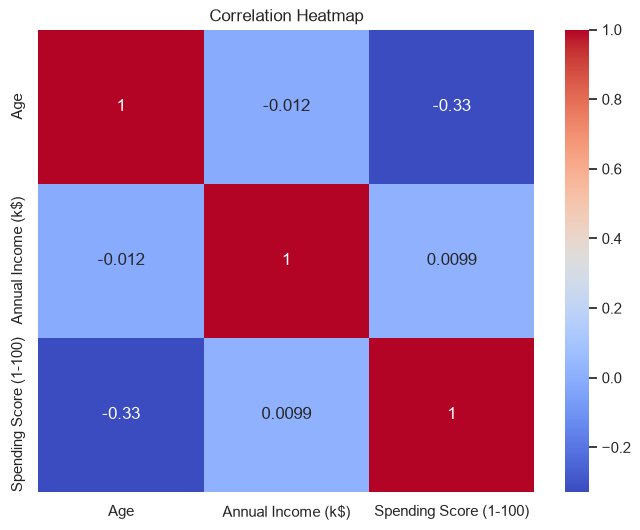

In [17]:
# Create the heatmap

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Interpretation

The correlation analysis shows that there are no strong linear relationships among the numerical variables in the dataset.

- The correlation between **Age** and **Annual Income (k$)** is **-0.012**, indicating almost no relationship.
- The correlation between **Annual Income (k$)** and **Spending Score (1-100)** is **0.0099**, suggesting that income has little influence on spending behavior in this dataset.
- The correlation between **Age** and **Spending Score (1-100)** is **-0.33**, indicating a weak negative relationship, where spending score tends to decrease slightly with increasing age.

Overall, the numerical variables are not strongly correlated, suggesting that each variable contributes different information for customer segmentation.

## 1.7 Data Preprocessing

Before applying clustering algorithms, the dataset was preprocessed to ensure that it was suitable for analysis. This involved removing unnecessary variables, converting categorical data into numerical format, and scaling the numerical features so that all variables contribute equally during clustering.

### 1.7.1 Removing the CustomerID Column

The `CustomerID` column is a unique identifier assigned to each customer. Since it does not contain any behavioural or demographic information, it does not contribute to customer segmentation and was removed from the dataset.

In [18]:
# Remove CustomerID

df = df.drop("CustomerID", axis=1)

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


### 1.7.2 Encoding the Gender Variable

The `Gender` column is a categorical variable containing text values. Since clustering algorithms require numerical input, the values were converted into numerical form using label encoding.

In [37]:
# Convert Gender into numerical values

df["Gender"] = df["Gender"].map({
    "Male":0,
    "Female":1
})

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,NaN,19,15,39,2
1,NaN,21,15,81,2
2,NaN,20,16,6,3
3,NaN,23,16,77,3
4,NaN,31,17,40,3


### 1.7.3 Feature Scaling

The numerical features in the dataset have different value ranges. Since K-Means clustering is a distance-based algorithm, variables with larger numerical values can dominate the distance calculations and influence the clustering results. To ensure that each feature contributes equally, I applied **StandardScaler**, which standardizes the features to a common scale while preserving the relationships among the observations.

In [21]:
# Create a StandardScaler object
scaler = StandardScaler()

# Scale the dataset
scaled_data = scaler.fit_transform(df)

# Display the first five rows of the scaled data
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)
scaled_df = scaled_df.round(2)
scaled_df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,-1.13,-1.42,-1.74,-0.43
1,-1.13,-1.28,-1.74,1.20
2,0.89,-1.35,-1.70,-1.72
3,0.89,-1.14,-1.70,1.04
4,0.89,-0.56,-1.66,-0.40


### Interpretation

The dataset was successfully preprocessed before applying the clustering algorithms. The `CustomerID` column was removed because it is only a unique identifier and does not contribute to customer segmentation. The `Gender` variable was converted into numerical values so that it could be used by the clustering algorithms.

Finally, feature scaling was performed using **StandardScaler**. Since the variables have different numerical ranges, scaling ensures that no single feature dominates the distance calculations used by K-Means clustering. The scaled dataset will be used for all clustering analyses in the next section.

# Part 2: Model Development and Validation

In this section, I developed and evaluated clustering models to identify meaningful customer segments. The preprocessed dataset was used to determine the optimal number of clusters, apply K-Means and Hierarchical Clustering algorithms, visualize the resulting clusters, and compare the performance of both approaches.

## 2.1 Feature Selection for Clustering

The preprocessed dataset contains four features: `Gender`, `Age`, `Annual Income (k$)`, and `Spending Score (1-100)`. Since these variables describe customer demographics and spending behaviour, they were selected for clustering. The scaled dataset (`scaled_df`) was used as the input for all clustering algorithms to ensure that each feature contributed equally during the distance calculations.

In [23]:
# Display the features used for clustering

print("Features used for clustering:")

list(scaled_df.columns)

Features used for clustering:


['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

## 2.2 Determining the Optimal Number of Clusters

Selecting an appropriate number of clusters is an important step in K-Means clustering. The Elbow Method was used to identify the optimal value of **k** by evaluating how the Within-Cluster Sum of Squares (WCSS) changes as the number of clusters increases. The optimal number of clusters is typically identified at the point where adding additional clusters results in only a small reduction in WCSS.

In [36]:
# Store WCSS values
wcss = []

# Test different numbers of clusters
for k in range(1, 11):

    # Create the K-Means model
    kmeans = KMeans(n_clusters=k, random_state=42)

    # Train the model
    kmeans.fit(scaled_df)

    # Store the WCSS value
    wcss.append(kmeans.inertia_)

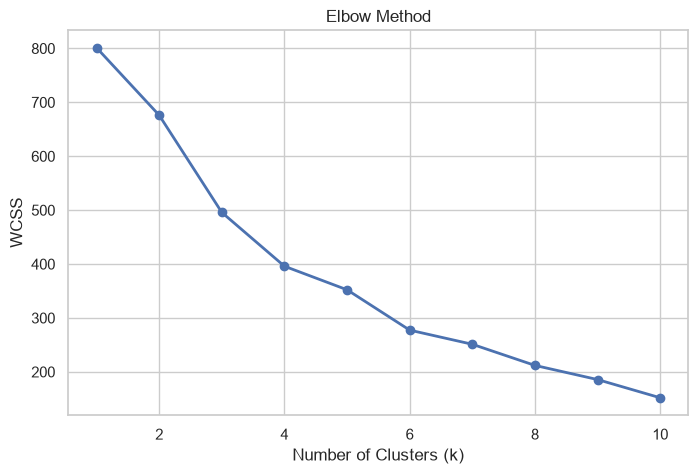

In [26]:
# Plot the Elbow Method

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o', linewidth=2)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters (k)")

plt.ylabel("WCSS")

plt.show()

### Interpretation

The Elbow Method was used to determine the optimal number of clusters for the K-Means algorithm. The WCSS decreases rapidly as the number of clusters increases from 1 to 4. After **k = 4**, the rate of decrease becomes more gradual, indicating that adding additional clusters provides only a small improvement.

Based on the elbow point observed in the graph, **4 clusters** were selected as the optimal number of clusters for the K-Means clustering analysis.

### Silhouette Score

To validate the choice of the optimal number of clusters, the Silhouette Score was calculated for different values of **k**. The Silhouette Score measures how well-separated the clusters are, with higher values indicating better clustering quality. The value of **k** with the highest or a reasonably high Silhouette Score, together with the Elbow Method, was selected for further analysis.

In [30]:
# Create the K-Means model with 4 clusters

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

# Fit the model and predict cluster labels

cluster_labels = kmeans.fit_predict(scaled_df)

# Calculate the Silhouette Score

score = silhouette_score(scaled_df, cluster_labels)

# Display the score

print("Silhouette Score:", round(score, 3))

Silhouette Score: 0.289


### Interpretation

The Silhouette Score for the K-Means clustering model with **4 clusters** is **0.289**. This indicates that the clustering solution provides a reasonable level of separation between the clusters, although some overlap exists among customer groups.

The result suggests that customers within the same cluster are generally more similar to one another than to customers in other clusters. Based on both the Elbow Method and the Silhouette Score, **4 clusters** were considered an appropriate choice for the subsequent clustering analysis.

## 2.3 K-Means Clustering

Based on the Elbow Method, **4 clusters** were selected for the K-Means algorithm. The clustering model was trained using the preprocessed and scaled dataset. After training, each customer was assigned to one of the four clusters, creating customer segments based on their similarities.

In [31]:
# Create the K-Means model

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

# Fit the model and assign cluster labels

scaled_df["Cluster"] = kmeans.fit_predict(scaled_df)

# Display the first five rows

scaled_df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,-1.13,-1.42,-1.74,-0.43,2
1,-1.13,-1.28,-1.74,1.20,2
2,0.89,-1.35,-1.70,-1.72,3
3,0.89,-1.14,-1.70,1.04,3
4,0.89,-0.56,-1.66,-0.40,3


In [32]:
# Display the number of customers in each cluster

scaled_df["Cluster"].value_counts().sort_index()

Cluster
0    58
1    34
2    42
3    66
Name: count, dtype: int64

### Interpretation

The K-Means algorithm successfully grouped all **200 customers** into **4 clusters**. Each customer was assigned to exactly one cluster based on the similarity of their scaled feature values.

The distribution of customers across the clusters is as follows:

- **Cluster 0:** 58 customers
- **Cluster 1:** 34 customers
- **Cluster 2:** 42 customers
- **Cluster 3:** 66 customers

The cluster sizes indicate that the customer segments are reasonably distributed, with no empty clusters. These cluster assignments will be used for further analysis and visualization.

In [33]:
# Add the cluster labels to the original dataset

df["Cluster"] = scaled_df["Cluster"]

# Display the first five rows

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,0,19,15,39,2
1,0,21,15,81,2
2,1,20,16,6,3
3,1,23,16,77,3
4,1,31,17,40,3


## 2.4 Hierarchical Clustering

Hierarchical Clustering was applied as an alternative clustering technique to compare its performance with K-Means. Unlike K-Means, Hierarchical Clustering does not require the initial specification of cluster centroids. In this analysis, Agglomerative Hierarchical Clustering with Ward linkage was used to group customers based on the similarity of their scaled features.

In [34]:
# Create the Hierarchical Clustering model

hierarchical = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

# Fit the model and assign cluster labels

scaled_df["Hierarchical Cluster"] = hierarchical.fit_predict(scaled_df)

# Display the first five rows

scaled_df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Hierarchical Cluster
0,-1.13,-1.42,-1.74,-0.43,2,2
1,-1.13,-1.28,-1.74,1.20,2,2
2,0.89,-1.35,-1.70,-1.72,3,1
3,0.89,-1.14,-1.70,1.04,3,1
4,0.89,-0.56,-1.66,-0.40,3,1


In [35]:
# Display the number of customers in each hierarchical cluster

scaled_df["Hierarchical Cluster"].value_counts().sort_index()

Hierarchical Cluster
0    58
1    66
2    42
3    34
Name: count, dtype: int64

### Interpretation

The Agglomerative Hierarchical Clustering algorithm successfully grouped all **200 customers** into **4 clusters**. The cluster sizes are similar to those obtained using the K-Means algorithm, although the cluster labels differ because each algorithm assigns labels independently.

The resulting clusters will be further examined using a dendrogram and compared with the K-Means clustering results.

### 2.4.1 Dendrogram

A dendrogram was generated to visualize the hierarchical clustering process. The dendrogram illustrates how individual observations are progressively merged into larger clusters based on their similarity. By selecting an appropriate cutting point on the dendrogram, the final number of clusters can be determined.

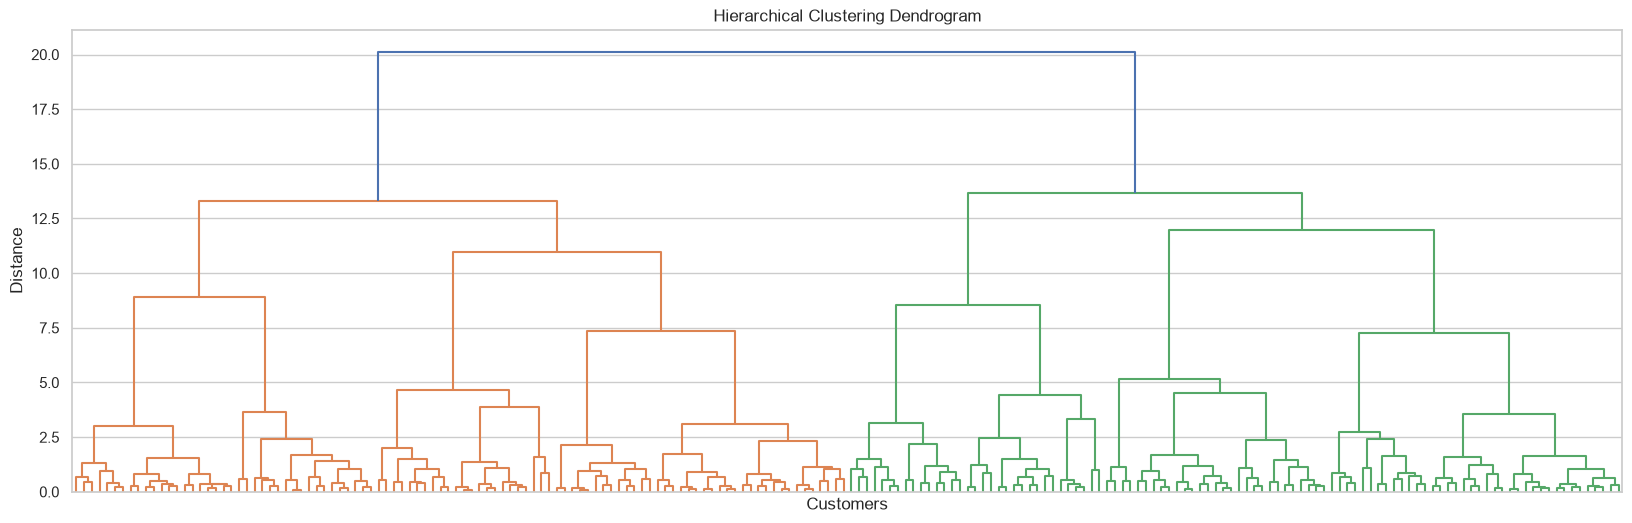

In [44]:
# Features used for clustering
clustering_data = scaled_df.drop(
    columns=["Cluster", "Hierarchical Cluster"]
)

# Generate the linkage matrix

linkage_matrix = linkage(
    clustering_data,
    method="ward"
)

# Plot the dendrogram

plt.figure(figsize=(20,6))

dendrogram(
    linkage_matrix,
    no_labels=True
)

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Customers")

plt.ylabel("Distance")

plt.show()

### Interpretation

The dendrogram illustrates how customers are progressively merged into larger clusters based on their similarity using Ward linkage. Clusters that merge at lower distances are more similar, whereas clusters that merge at higher distances are more distinct.

The dendrogram shows clear hierarchical grouping among the customers, supporting the presence of meaningful customer segments. The clustering structure is consistent with the use of **4 clusters** selected during the K-Means analysis.

## 2.5 Cluster Visualization using PCA

The clustering results were visualized using **Principal Component Analysis (PCA)**. Since the dataset contains four features, PCA was applied to reduce the data to two principal components while preserving as much variation as possible. This enables the customer clusters to be visualized in a two-dimensional scatter plot.

In [45]:
# Create a PCA model with two components

pca = PCA(n_components=2)

# Transform the scaled data

pca_data = pca.fit_transform(
    clustering_data
)

# Create a DataFrame for the PCA results

pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1", "PC2"]
)

# Add cluster labels

pca_df["Cluster"] = scaled_df["Cluster"]

# Display the first five rows

pca_df.head()

,PC1,PC2,Cluster
0,-0.401840,-0.479082,2
1,-1.424268,-0.317984,2
2,0.050954,-1.889839,3
3,-1.698869,-1.614153,3
4,-0.312193,-1.801982,3


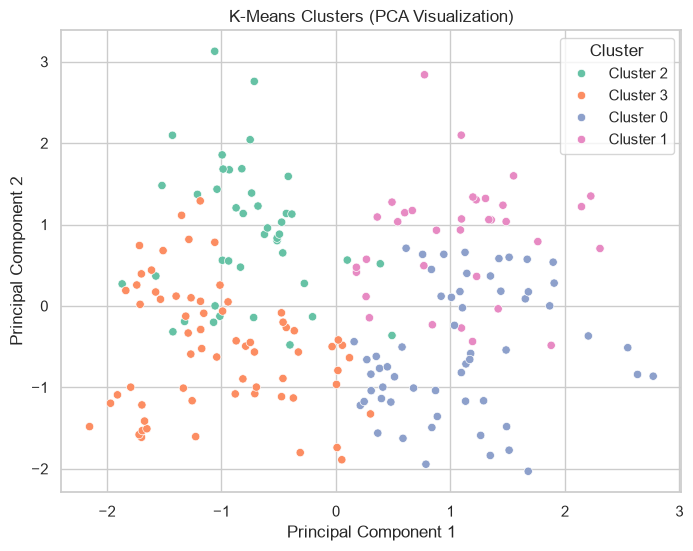

In [53]:
# Create a copy of the PCA DataFrame
plot_df = pca_df.copy()

# Rename the cluster labels
plot_df["Cluster"] = plot_df["Cluster"].map({
    0: "Cluster 0",
    1: "Cluster 1",
    2: "Cluster 2",
    3: "Cluster 3"
})

# Plot the K-Means clusters
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2"
)

plt.title("K-Means Clusters (PCA Visualization)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(True)

plt.show()

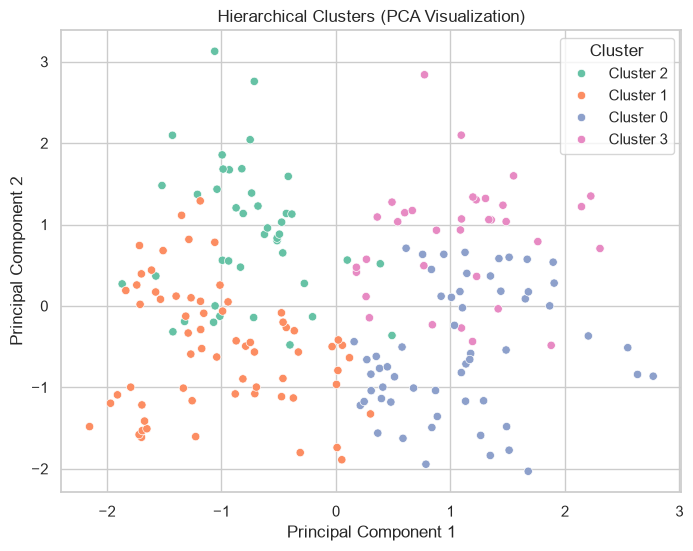

In [55]:
# Create a copy of the PCA DataFrame
plot_df = pca_df.copy()

# Rename the hierarchical cluster labels
plot_df["Hierarchical Cluster"] = plot_df["Hierarchical Cluster"].map({
    0: "Cluster 0",
    1: "Cluster 1",
    2: "Cluster 2",
    3: "Cluster 3"
})

# Plot the Hierarchical clusters
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=plot_df,
    x="PC1",
    y="PC2",
    hue="Hierarchical Cluster",
    palette="Set2"
)

plt.title("Hierarchical Clusters (PCA Visualization)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(True)

plt.show()

### Interpretation

Principal Component Analysis (PCA) was used to reduce the four-dimensional dataset into two principal components for visualization. The scatter plots show that both K-Means and Hierarchical Clustering successfully grouped customers into four distinct clusters.

Although some overlap exists between neighbouring clusters, the customer groups are generally well separated. The visualizations indicate that both clustering algorithms identify similar segmentation patterns, supporting the results obtained from the Elbow Method and the Silhouette Score.

## 2.6 Comparison of Clustering Methods

Both K-Means and Agglomerative Hierarchical Clustering were applied to segment the customers into four groups.

| Aspect | K-Means | Hierarchical Clustering |
|--------|---------|-------------------------|
| Number of Clusters | Requires specifying the number of clusters before training | Produces a hierarchy of clusters that can be visualized using a dendrogram |
| Clustering Process | Iteratively updates cluster centroids | Progressively merges similar observations |
| Speed | Faster for large datasets | Computationally more expensive for large datasets |
| Visualization | Cluster assignments can be visualized using PCA | Hierarchical relationships can be visualized using a dendrogram |
| Results | Produced four meaningful customer segments | Produced a similar clustering structure with different cluster labels |

Overall, both algorithms produced comparable customer segments. However, K-Means is computationally more efficient and easier to interpret for this dataset.

## 2.7 Selection of the Best Clustering Solution

Based on the analysis, the **K-Means clustering algorithm** was selected as the preferred clustering solution.

The Elbow Method suggested **4 clusters** as the optimal choice, and the corresponding Silhouette Score of **0.289** indicated a reasonable clustering structure. The PCA visualization also showed that the clusters were generally well separated, although some overlap existed between neighbouring groups.

While Hierarchical Clustering produced similar customer segments, K-Means was selected because it is simpler to interpret, computationally efficient, and well suited for customer segmentation problems involving structured numerical data.

# Part 3: Interpretation and Insights

## 3.1 Key Findings

The analysis successfully identified meaningful customer segments using both **K-Means** and **Agglomerative Hierarchical Clustering**. Before applying the clustering algorithms, the dataset was explored, cleaned, and preprocessed. The exploratory analysis showed that the dataset contained no missing values and only two potential high-income outliers, which were retained because they represented valid customer records rather than data entry errors.

The Elbow Method suggested that **4 clusters** were appropriate for customer segmentation. The clustering solution was further evaluated using the Silhouette Score, which produced a value of **0.289**, indicating a reasonable clustering structure. PCA visualization demonstrated that the customer groups were generally distinguishable, although some overlap existed between neighbouring clusters. Hierarchical Clustering produced a similar grouping pattern, providing additional confidence in the clustering results.

The customer groups were formed based on similarities in the four selected features: **Gender**, **Age**, **Annual Income (k$)**, and **Spending Score (1–100)**. Customers with similar demographic characteristics and spending behaviour were assigned to the same cluster, while customers with different characteristics were placed into different clusters. This approach enables the identification of distinct customer segments that can support targeted business strategies.

## 3.2 Actionable Insights

The identified customer segments provide valuable information that can help the shopping mall improve its marketing strategies and customer engagement.

Different customer groups may require different promotional approaches. Customers with higher spending scores may respond well to loyalty rewards, exclusive discounts, and premium membership programs. Customers with lower spending scores may benefit from promotional campaigns, seasonal discounts, and personalised offers that encourage increased spending.

Similarly, customer demographics such as age and annual income can be used to design targeted marketing campaigns. Younger customers may respond better to digital marketing and social media promotions, while customers with higher annual incomes may be interested in premium products and personalised shopping experiences.

Customer segmentation also enables the business to allocate marketing resources more effectively by focusing campaigns on the needs and preferences of each customer group rather than applying the same strategy to all customers.

## 3.3 Practical Implications

The clustering results demonstrate how unsupervised machine learning can support business decision-making. Instead of treating all customers as a single group, the shopping mall can better understand differences in customer behaviour and purchasing patterns.

The identified customer segments can be used for customer relationship management, targeted advertising, inventory planning, and personalised recommendation systems. Businesses can also monitor how customers move between different segments over time and evaluate the effectiveness of marketing campaigns based on changes in customer behaviour.

Overall, customer segmentation can improve customer satisfaction while helping businesses increase sales, optimise marketing expenditure, and strengthen long-term customer relationships.

## 3.4 Limitations

Although the analysis produced meaningful customer segments, several limitations should be considered.

The dataset contains information for only **200 customers**, which represents a relatively small sample size. In addition, the clustering analysis was based on only four customer attributes: Gender, Age, Annual Income, and Spending Score. Many other factors that influence customer behaviour, such as purchase history, shopping frequency, preferred product categories, customer location, seasonal trends, and customer satisfaction, were not available in the dataset.

The Silhouette Score of **0.289** also indicates that while the clustering solution is reasonable, some overlap exists between customer groups. This suggests that customer behaviour is more complex than can be fully captured using the available variables.

Finally, customer preferences and spending patterns may change over time, whereas this dataset represents customer information collected at a single point in time.

## 3.5 Recommendations and Future Work

Future analyses could be improved by incorporating additional customer information such as purchase history, transaction frequency, product preferences, customer lifetime value, online shopping behaviour, and geographic location. Including these variables would likely produce more informative customer segments.

Additional clustering algorithms, such as **DBSCAN**, **Gaussian Mixture Models (GMM)**, or **Spectral Clustering**, could also be evaluated and compared with K-Means and Hierarchical Clustering to determine whether they provide better segmentation for this dataset.

Furthermore, cluster quality could be assessed using additional evaluation metrics such as the **Calinski-Harabasz Index** and the **Davies-Bouldin Index** alongside the Silhouette Score. Applying these methods would provide a more comprehensive assessment of clustering performance.

Overall, incorporating richer customer data and evaluating multiple clustering approaches would strengthen the analysis and support more effective business decision-making.